In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ripser import ripser

True

In [3]:
import gudhi

gudhi available 3.11.0


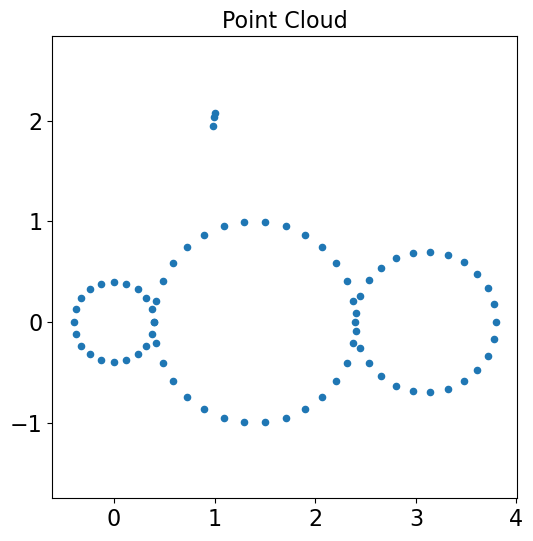

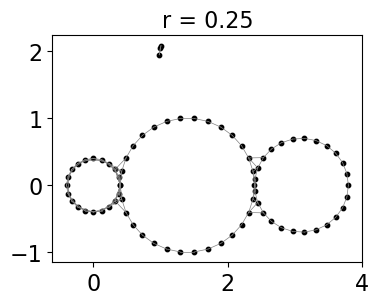

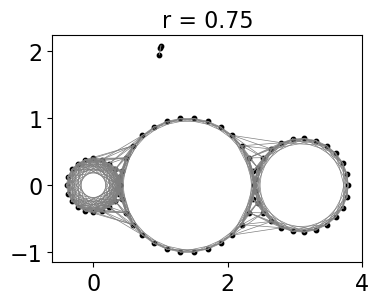

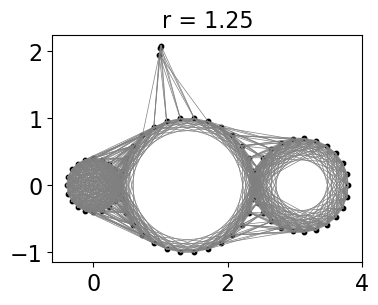

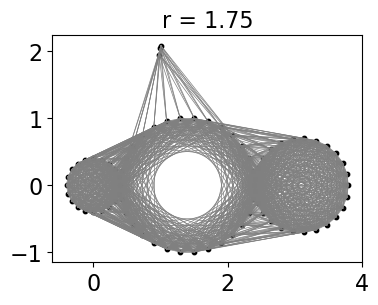

In [50]:
from persim import plot_diagrams
from scipy.spatial.distance import pdist, squareform

plt.rcParams.update({
    "font.size": 16,          # default text size
    "axes.titlesize": 16,     # title
    "axes.labelsize": 16,     # x/y labels
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,})

def circle(cx, cy, r, n):
    t = np.linspace(0, 2*np.pi, n, endpoint=False)
    return np.c_[cx + r*np.cos(t), cy + r*np.sin(t)]

# Radii
R_small = 0.4
R_big   = 1.0
R_med   = 0.7


x0 = 0
x1 = x0 + (R_small + R_big)   
x2 = x1 + (R_big + R_med)       

pts_small = circle(x0, 0, R_small, 20)
pts_big   = circle(x1, 0, R_big,   30)
pts_med   = circle(x2, 0, R_med,   25)
cluster_center = np.array([1.0, 2.0])
cluster = cluster_center + 0.05 * np.random.randn(3, 2)
pts = np.vstack([pts_small, pts_big, pts_med, cluster])

plt.figure(figsize=(6,6))
plt.scatter(pts[:,0], pts[:,1], s=20)
plt.axis("equal")
plt.title("Point Cloud")
plt.savefig("pointcloud.svg", format='svg', dpi=300)
plt.show()

D = squareform(pdist(pts))
results = ripser(D, distance_matrix=True, maxdim=1)
dgms = results['dgms']

epsilons = [0.25, 0.75, 1.25, 1.75]

for eps in epsilons:
    fig, ax = plt.subplots(figsize=(4,6)) 

    # Scatter points
    ax.scatter(pts[:,0], pts[:,1], s=10, color='black')

    # Plot edges
    for i in range(len(pts)):
        for j in range(i+1, len(pts)):
            if D[i,j] <= eps:
                ax.plot([pts[i,0], pts[j,0]], [pts[i,1], pts[j,1]], 
                        linewidth=0.5, color="gray", alpha=1)  

    ax.set_aspect('equal')
    ax.set_title(f"r = {eps}")
    fig.savefig(f"edges_eps_{eps}.svg", format='svg', dpi=300)

    plt.show()



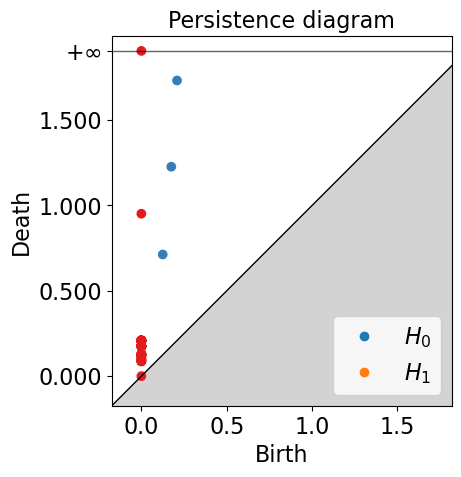

In [46]:
gudhi_persistence = []
for d, arr in enumerate(dgms):
    for b, dec in arr:
        gudhi_persistence.append((int(d), (float(b), float(dec))))

ax = gudhi.plot_persistence_diagram(persistence=gudhi_persistence)
for collection in ax.collections:
    collection.set_alpha(1)

handles = [plt.Line2D([], [], marker='o', linestyle='', color='C0', markersize=6),
           plt.Line2D([], [], marker='o', linestyle='', color='C1', markersize=6)]
labels = [r'$H_0$', r'$H_1$']
ax.legend(handles=handles, labels=labels)#, title='Dimension')
ax.set_aspect('equal', 'box')
L = max([dec for _, (b, dec) in gudhi_persistence])
ax.plot([-0.05, L], [-0.05, L], 'k--', linewidth=1)
plt.savefig("persistence_diag.svg", format='svg', dpi=300)
plt.show()


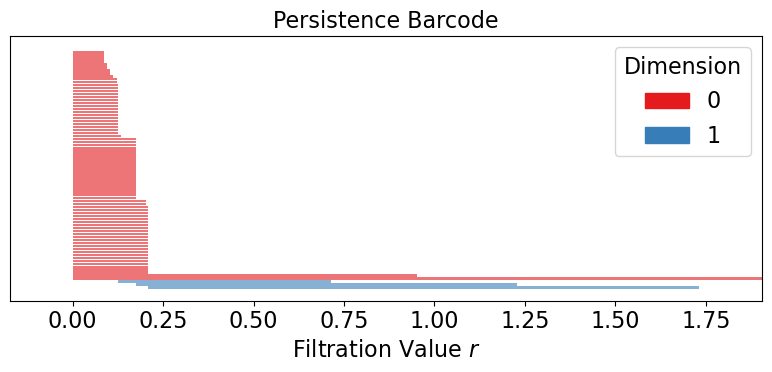

In [45]:
gudhi_persistence = []
for dim, arr in enumerate(dgms):
    for (b, d) in arr:
        gudhi_persistence.append((int(dim), (float(b), float(d))))

gudhi_persistence_sorted = sorted(gudhi_persistence, key=lambda x: x[0], reverse=True)

fig, ax = plt.subplots(figsize=(8,4))
ax = gudhi.plot_persistence_barcode(persistence=gudhi_persistence_sorted,axes=ax)
for line in ax.get_lines():
    line.set_alpha(1)

plt.title("Persistence Barcode")
ax.set_xlabel(r'Filtration Value $r$')
plt.tight_layout()
fig.savefig("persistence_barcode.svg", format='svg', dpi=300)
plt.show()

